In [34]:
%pip install -U transformers datasets sacrebleu sentencepiece evaluate

Note: you may need to restart the kernel to use updated packages.


In [35]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# English->Spanish
tok_es = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-es")
mod_es = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-es").to(device)

# English->Portuguese
tok_pt = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-pt")
mod_pt = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-pt").to(device)

def translate_es(text, max_new_tokens=128, num_beams=5):
    enc = tok_es([text], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_es.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens)
    return tok_es.batch_decode(out, skip_special_tokens=True)[0]

def translate_pt(text, max_new_tokens=128, num_beams=5):
    enc = tok_pt([text], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        out = mod_pt.generate(**enc, num_beams=num_beams, max_new_tokens=max_new_tokens)
    return tok_pt.batch_decode(out, skip_special_tokens=True)[0]

print(translate_es("The study focuses on electronic devices and materials."))
print(translate_pt("The study focuses on electronic devices and materials."))


c:\Users\jeeva\anaconda3\Lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


OSError: Helsinki-NLP/opus-mt-en-pt is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [26]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

# seq2seq collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# Task prefixes (mT5 uses text prompts)
PREFIX = {
    "es": f"translate {SRC_LANG_NAME} to {TGT_LANGS['es']}: ",
    "pt": f"translate {SRC_LANG_NAME} to {TGT_LANGS['pt']}: ",
}
print(PREFIX)


c:\Users\jeeva\anaconda3\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


{'es': 'translate English to Spanish: ', 'pt': 'translate English to Portuguese: '}


In [27]:
GLOSSARY = {
    "polymerase chain reaction": {
        "es": "reacción en cadena de la polimerasa",
        "pt": "reação em cadeia da polimerase",
    },
    "confidence interval": {
        "es": "intervalo de confianza",
        "pt": "intervalo de confiança",
    },
}

def apply_glossary(text: str, tgt_lang_code: str) -> str:
    # tgt_lang_code is "es" or "pt" here
    out = text
    for en_term, mapping in GLOSSARY.items():
        if tgt_lang_code in mapping:
            out = out.replace(en_term, mapping[tgt_lang_code])
    return out


In [28]:
HF_DATASETS = {
    "en-es": {"path": "opus100", "config": "en-es"},
    "en-pt": {"path": "opus100", "config": "en-pt"},
}

def load_raw_by_pair(lang_pair: str, split: str):
    spec = HF_DATASETS[lang_pair]
    ds = load_dataset(spec["path"], spec["config"], split=split)
    ds = ds.select(range(min(MAX_SAMPLES_PER_LANG, len(ds))))
    src_key, tgt_key = lang_pair.split("-")  # "en-es" -> ("en","es")

    def norm(ex):
        if "translation" in ex:
            return {"src_text": ex["translation"][src_key], "tgt_text": ex["translation"][tgt_key]}
        elif "source" in ex and "target" in ex:
            return {"src_text": ex["source"], "tgt_text": ex["target"]}
        else:
            return {"src_text": ex[src_key], "tgt_text": ex[tgt_key]}

    tgt_lang_short = tgt_key  # "es" or "pt"
    ds = ds.map(norm, remove_columns=ds.column_names)
    ds = ds.map(lambda ex: {"tgt_lang": tgt_lang_short})
    return ds

train_raw_es = load_raw_by_pair("en-es", "train")
train_raw_pt = load_raw_by_pair("en-pt", "train")
valid_raw_es = load_raw_by_pair("en-es", "validation").select(range(min(EVAL_SAMPLES, MAX_SAMPLES_PER_LANG)))
valid_raw_pt = load_raw_by_pair("en-pt", "validation").select(range(min(EVAL_SAMPLES, MAX_SAMPLES_PER_LANG)))

print("Train ES/PT sizes:", len(train_raw_es), len(train_raw_pt))
print("Valid ES/PT sizes:", len(valid_raw_es), len(valid_raw_pt))


Train ES/PT sizes: 800 800
Valid ES/PT sizes: 200 200


In [29]:
def make_preprocess_fn(tgt_short: str):
    """
    For mT5 we add a text prefix like:
      "translate English to Spanish: <src>"
    and tokenize labels with `text_target`.
    """
    prefix = PREFIX[tgt_short]
    def _fn(batch):
        # build prefixed sources
        sources = [prefix + s for s in batch["src_text"]]
        # apply glossary to targets (optional hybrid)
        targets = [apply_glossary(t, tgt_short) for t in batch["tgt_text"]]

        # tokenize inputs and labels (new API supports text_target directly)
        model_inputs = tokenizer(
            sources,
            max_length=MAX_SOURCE_LEN,
            truncation=True,
        )
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                targets,
                max_length=MAX_TARGET_LEN,
                truncation=True,
            )
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs
    return _fn

pre_es = make_preprocess_fn("es")
pre_pt = make_preprocess_fn("pt")

train_ds_es = train_raw_es.map(pre_es, batched=True, remove_columns=train_raw_es.column_names)
train_ds_pt = train_raw_pt.map(pre_pt, batched=True, remove_columns=train_raw_pt.column_names)
valid_ds_es = valid_raw_es.map(pre_es, batched=True, remove_columns=valid_raw_es.column_names)
valid_ds_pt = valid_raw_pt.map(pre_pt, batched=True, remove_columns=valid_raw_pt.column_names)

train_ds = interleave_datasets([train_ds_es, train_ds_pt], seed=SEED)
valid_ds = interleave_datasets([valid_ds_es, valid_ds_pt], seed=SEED)

print("Tokenized train/valid sizes:", len(train_ds), len(valid_ds))


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenized train/valid sizes: 1600 400


c:\Users\jeeva\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [30]:
# === Version-agnostic TrainingArguments + Trainer (drop-in for your Cell 8) ===
import numpy as np, evaluate, inspect
from transformers import TrainingArguments, Trainer

bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = bleu_metric.compute(predictions=decoded_preds, references=[[l] for l in decoded_labels])
    return {"bleu": result["score"]}

# Put all the args you WANT...
wanted_kwargs = dict(
    output_dir=f"{PROJECT_DIR}/checkpoints_tiny",
    evaluation_strategy="no",      # will be dropped if unsupported
    save_strategy="no",            # will be dropped if unsupported
    logging_steps=50,
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=5e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.05,
    weight_decay=0.01,
    bf16=use_bf16,
    fp16=use_fp16,
    dataloader_num_workers=0,                 # Windows/Notebook-safe; dropped if unsupported
    dataloader_pin_memory=(device == "cuda"), # dropped if unsupported
    report_to="none",
    no_cuda=(device != "cuda"),
)

# ...then filter to ONLY what your installed version accepts.
accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
filtered_kwargs = {k: v for k, v in wanted_kwargs.items() if k in accepted}

# Helpful print so you see what got used
dropped = sorted(set(wanted_kwargs) - set(filtered_kwargs))
print("Using TrainingArguments keys:", sorted(filtered_kwargs.keys()))
if dropped:
    print("Dropped unsupported keys:", dropped)

args = TrainingArguments(**filtered_kwargs)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=None,          # keep None for speed; add valid_ds if you want eval
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,  # safe even if we don't eval during train
)

print("🚀 Training (version-agnostic args)…")
trainer.train()
print("✅ Training finished.")


Using TrainingArguments keys: ['bf16', 'dataloader_num_workers', 'dataloader_pin_memory', 'fp16', 'gradient_accumulation_steps', 'learning_rate', 'logging_steps', 'lr_scheduler_type', 'max_steps', 'no_cuda', 'output_dir', 'per_device_train_batch_size', 'report_to', 'save_strategy', 'warmup_ratio', 'weight_decay']
Dropped unsupported keys: ['evaluation_strategy']
🚀 Training (version-agnostic args)…


C:\Users\jeeva\AppData\Local\Temp\ipykernel_24236\3987308342.py:48: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,27.299800
100,23.611600
150,19.341700
200,16.191300
250,13.725200
300,11.964900
350,10.778100
400,9.835100
450,9.081500
500,8.488900


✅ Training finished.


In [33]:
def translate(text: str, tgt_short: str, max_new_tokens=128, num_beams=4):
    """
    Translate any English string to Spanish (tgt_short='es') or Portuguese ('pt').
    """
    prefix = PREFIX[tgt_short]
    enc = tokenizer([prefix + text], return_tensors="pt", padding=True, truncation=True, max_length=MAX_SOURCE_LEN).to(device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, num_beams=num_beams)
    return tokenizer.batch_decode(out, skip_special_tokens=True)[0]

print(translate("Polymerase chain reaction is widely used in molecular biology.", "es"))
print(translate("Polymerase chain reaction is widely used in molecular biology.", "pt"))


s
%),.


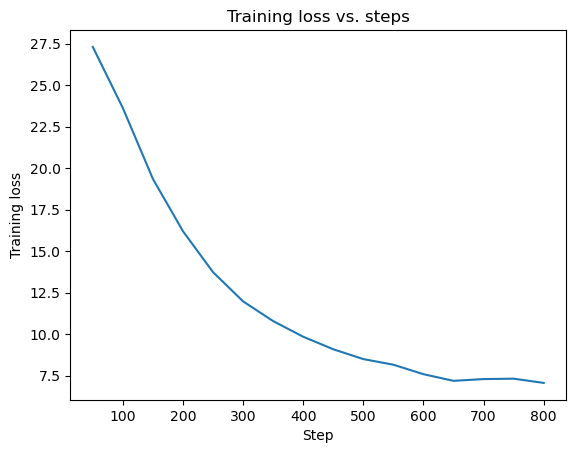

In [32]:
# Plot training loss over steps from Hugging Face Trainer logs
import matplotlib.pyplot as plt

# Collect loss points from Trainer's in-memory log
loss_points = [(e["step"], e["loss"]) for e in getattr(trainer.state, "log_history", []) if "loss" in e]

if not loss_points:
    print("No loss logs found. Make sure training ran with logging_steps > 0.")
else:
    steps, losses = zip(*loss_points)
    plt.figure()
    plt.plot(steps, losses)
    plt.xlabel("Step")
    plt.ylabel("Training loss")
    plt.title("Training loss vs. steps")
    plt.show()
